In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
from datetime import datetime
import pickle # for saving simulations
from pybamm import exp, constants
from scipy.optimize import least_squares
from scipy.optimize import minimize
from scipy.signal import savgol_filter
import gzip
import time
import optuna
import openpyxl
#import galvani
from galvani import res2sqlite
import sqlite3
import cellpy
import Siegel2022
# %matplotlib ipympl

## Setup simulation

### Load Biologic and vdf data

In [2]:
vdf_data0=pd.read_csv('Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1_AuxDat_TC40_20230228_164816.csv', sep='\t',skiprows=[0,1,2,3,5],header=0)
res_file = ["Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1.res", 
            "Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RATE_1_P25C_P5P0PSI_20230302_R1.res"]

c = cellpy.get(res_file, mass=1)

Could not set custom log-dir - non-existing directory
Dir: c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\degradation_model\tuning_umbl2022feb\cellpy_data\logs
Using current directory instead: c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\degradation_model\tuning_umbl2022feb


In [3]:
# Select cycler data
start = c.data.raw[-c.data.raw.current==0].first_valid_index() # start of rest before hppc
end = c.data.raw[abs(-c.data.raw.current - (-1.75)) <0.01].first_valid_index()-1 # end of rest after hppc
c.data.raw['Timestamp_s'] = c.data.raw.date_time.values.astype(np.int64)/10**9+3600*4-1855-90# UTC offset for EST, need to also be cognizent of DST?

cycler_data = c.data.raw.loc[start:end]
t_data0 = cycler_data.test_time.to_numpy()
t_data0 = t_data0-t_data0[0]
I_data0 = -cycler_data.current.to_numpy() # pybamm I>0 on discharge 
V_data0 = cycler_data.voltage.to_numpy()

# Select corresponding vdf_data
vdf_data0['Timestamp_s'] = vdf_data0['Timestamp']/1000 # epoch time time in ms and convert to s
start_vdf = np.argmin(abs(vdf_data0['Timestamp_s'] - c.data.raw.Timestamp_s[start]))
end_vdf = np.argmin(abs(vdf_data0['Timestamp_s'] - c.data.raw.Timestamp_s[end])) 
vdf_data = vdf_data0.iloc[start_vdf:end_vdf]
t_data_vdf = vdf_data['Timestamp_s'] -  cycler_data.Timestamp_s.iloc[0] #min([cycler_data.Timestamp_s.iloc[0],vdf_data['Timestamp_s'].iloc[0]])
V_neg_data = vdf_data['Vneg']
V_pos_data = vdf_data['Vpos']

# check that cycler and vdf data are aligned
print(f"Start timestamps error: {cycler_data.Timestamp_s.iloc[0]-vdf_data['Timestamp_s'].iloc[0]}", "s")
print(f"End timestamps error: {cycler_data.Timestamp_s.iloc[-1]-vdf_data['Timestamp_s'].iloc[-1]}", "s")


Start timestamps error: 0.35899996757507324 s
End timestamps error: 4.158999919891357 s


### Downsample current profile 

C:\Users\Vivian\AppData\Local\Temp\ipykernel_15460\3116262945.py:5: RuntimeWarning: divide by zero encountered in divide
  deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_15460\3116262945.py:6: RuntimeWarning: invalid value encountered in divide
  di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)


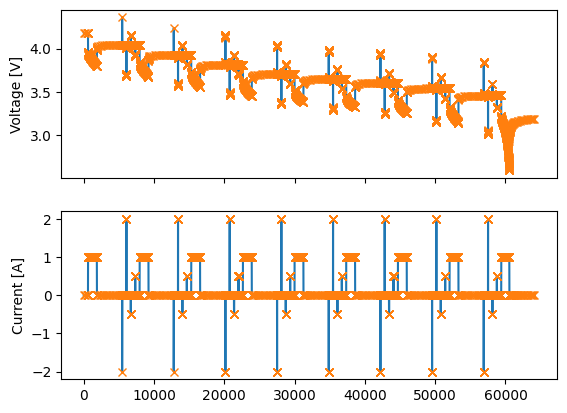

In [4]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_data, I_data, V_data = downsample_data(t_data0,I_data0,V_data0,5e-3,.5,230)
fig,ax = plt.subplots(2,1, sharex=True)
ax1 = ax.flat[0]
ax1.plot(t_data0,V_data0)
ax1.plot(t_data,V_data,'x')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data0,I_data0)
ax2.plot(t_data,I_data,'x')
ax2.set_ylabel('Current [A]')
plt.show()

In [11]:
# current profile for running sim
df0 = pd.DataFrame({'t':t_data, 'I':I_data})
df = df0.drop_duplicates(subset='t', keep="last")
current_profile = df.to_numpy() 
# experiment = pybamm.Experiment(
#     ["Rest for 1 second", 
#     pybamm.step.current(current_profile),
#     ]
#     , period = "1 second"
#     )

### Set up parameters

In [12]:
# cathode diffusion
def NMC_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("posDiffusion")
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# anode diffusion
def graphite_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("negDiffusion")
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# cathode kinetics
def NMC_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("posKinetics")
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (
        m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# anode kinetics
def graphite_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("negKinetics")
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)

def electrolyte_diffusivity_Dix(c_e, T):
    """
    Diffusivity of LiPF6 in EC:EMC vol 3:7 with 2 wt% VC as a function of
    ion concentration.
    The original data is from [1]. The Fitting Funciton is from [2]

    References
    ----------
    .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve Porous
    Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells." 2023
    J. Electrochem. Soc. 170 083503
    DOI 10.1149/1945-7111/aceca8
       [2] Lars Ole Valøen and Jan N. Reimers. "Transport Properties of LiPF6-Based
       Li-Ion Battery Electrolytes." 2005 J. Electrochem. Soc. 152 A882 Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte diffusivity
    """

    # Diffusivity in 10E-10 m^2/s = 0.0001*10^((D00+ D01 / (T -
    # ((Tg0 + Conc * Tg1))))+ (D10+ D11/ (T - ((Tg0 + Conc* Tg1)))) * Conc)
    # Where Conc is in units of M and T is in K

    D00 = -487.2
    D01 = -28530000
    Tg0 = 58320
    Tg1 = 50.31
    D10 = -52.79
    D11 = -3061000
    c_e_M = c_e / 1000
    D_c_e = (
        (10**-10)
        * 0.0001
        * 10
        ** (
            (D00 + D01 / (T - ((Tg0 + c_e_M * Tg1))))
            + (D10 + D11 / (T - ((Tg0 + c_e_M * Tg1)))) * c_e_M
        )
    )

    return D_c_e*pybamm.InputParameter("electDiff")


def electrolyte_conductivity_Dix(c_e, T):
    """
    Conductivity of LiPF6 in 3:7 EC:DMC as a function of ion concentration. The original
    data is from [1].

    References
    ----------
    ..     .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve
    Porous Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells."
    2023 J. Electrochem. Soc. 170 083503 DOI 10.1149/1945-7111/aceca8.

    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte conductivity
    """
    k_Kmax = 3.58e-7
    k_Cmax = 4.84e-6
    k_a = 0.4793
    k_P2 = -0.3299
    k_P1 = 2.22e-14
    k_Ea = 13490
    k_Rg = 8.314
    k_T0 = 162.5
    # Conductivity in mS/cm = 1000*(k_Kmax* (Conc / K_Cmax) ^ k_a *
    # EXP(k_P2 * (Conc – k_Cmax) ^ 2 – k_P1 * (Conc- K_Cmax) / K_Cmax)
    # * EXP(-k_Ea / k_Rg * (1 / T - 1 / K_T0)))
    # Where Conc is in units of M and T is in K
    # convert to S/m
    c_e_M = c_e / 1000

    sigma_e = 100 * (
        k_Kmax
        * (c_e_M / k_Cmax) ** k_a
        * pybamm.exp(k_P2 * (c_e_M - k_Cmax) ** 2 - k_P1 * (c_e_M - k_Cmax) / k_Cmax)
        * pybamm.exp(-k_Ea / k_Rg * (1 / T - 1 / k_T0))
    )

    return sigma_e*pybamm.InputParameter("electCond")

In [13]:
spme = pybamm.lithium_ion.SPMe()
#spme = pybamm.lithium_ion.DFN()

param_dict = Siegel2022.get_parameter_values()
parameter_values = pybamm.ParameterValues(param_dict)  
param0 = 0.5*6.748678940622972e-14
param1 = 4*1.0122133310725916e-14
param2 = 0.25*1.3715539078341868e-07
param3 = 1.2178795378580133e-06


param = spme.param
Cap=3.5
x_100=0.867
y_100=0.3083
initial_soc=0.9

C_n_init = 4.0458 
C_p_init = 5.4828

#Cell 901 update
Cap=3.004
x_100=0.74
y_100=0.3083
C_n_init = 4.5 
C_p_init = 4.6

x_0=x_100-Cap/C_n_init
y_0=y_100+Cap/C_p_init
x = x_0 + initial_soc * (x_100 - x_0)
y = y_0 - initial_soc * (y_0 - y_100)

x_init = x # 0.861
y_init = y # 0.3083
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Lower voltage cut-off [V]": 2.4, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

#initial_voltage_string="4.1 V"
#print(V_data[0])
#[xinitV,yinitV]=pybamm.lithium_ion.get_initial_stoichiometries(str(V_data[0]) +' V',parameter_values)

# Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
# initial_voltage=V_data[0]
model_initV = pybamm.BaseModel()
param_initV = pybamm.LithiumIonParameters()


U_n = param_initV.n.prim.U
U_p = param_initV.p.prim.U
T_ref = param_initV.T_ref
Q_init=0
a0=y_100-(Q_init-Cap)/C_p_init
a1=x_100+(Q_init-Cap)/C_n_init
Q_init=Cap
a2=y_100-(Q_init-Cap)/C_p_init
a3=x_100+(Q_init-Cap)/C_n_init
Q_init = pybamm.Variable("Q_init")
model_initV.algebraic = {Q_init: U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref) - V_data[0]}
model_initV.initial_conditions = {Q_init: Cap}
model_initV.variables = {
    "Q_init": Q_init,
}

sim = pybamm.Simulation(model_initV, parameter_values=parameter_values)
sol = sim.solve([0])
for var in ["Q_init"]:
    print(var, ":", sol[var].data[0])
Q_init=sol["Q_init"].data[0]

xinitV=x_100+(Q_init-Cap)/C_n_init
yinitV=y_100-(Q_init-Cap)/C_p_init
cs_n_init = parameter_values.evaluate(xinitV* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(yinitV* param.p.prim.c_max)

parameter_values.update(
    {
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
    },check_already_exists=False,)


parameter_values.update(
    {
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
        "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
        "Electrolyte diffusivity [m2.s-1]": electrolyte_diffusivity_Dix,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity_Dix,
        "Cation transference number": 0.25,
        "Separator porosity": 0.2,
        "Positive electrode porosity": 0.2,
        "Negative electrode porosity": 0.15,
        "Separator thickness [m]": 2*1.2e-05,
        })                 

L_n = spme.param.n.L  # Negative electrode thickness [m]
L_s = spme.param.s.L  # Separator thickness [m]
L_ref = L_n + L_s / 2  # Reference electrode position [m]

spme.insert_reference_electrode(L_ref)


Q_init : 2.969390978357389


## Run simulation

In [14]:
current_interpolant = pybamm.Interpolant(t_data, I_data, pybamm.t)
parameter_values["Current function [A]"] = current_interpolant
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe")  #,dt_max=50
sim = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver)#,  , experiment=experiment, var_pts=var_pts,    submesh_types=submesh_types,)

# Run initial simulation
sol = sim.solve(
    t_eval=t_data,
    inputs = {
    "posDiffusion": param0, 
    "negDiffusion": param1, 
    "posKinetics": param2,
    "negKinetics": param3,
    "electCond" : 1,
    "electDiff" : 1
    })


## Parameterization with optuna

In [15]:
def objective(trial):

    # define parameters and suggested ub and lb 
    k_min = 1e-1
    k_max = 10
    k_D_p = trial.suggest_float("k_D_p", k_min, k_max)
    k_D_n = trial.suggest_float("k_D_n", k_min, k_max)
    k_i0p = trial.suggest_float("k_i0p", k_min, k_max)
    k_i0n = trial.suggest_float("k_i0n", k_min, k_max)
    k_sigma_e = trial.suggest_float("k_sigma_e", k_min, k_max)
    k_D_e = trial.suggest_float("k_D_e", k_min, k_max)

    # solve model model
    try:
        sol = sim.solve(
            t_eval=t_data,
            inputs = {
            "posDiffusion": param0*k_D_p, 
            "negDiffusion": param1*k_D_n, 
            "posKinetics": param2*k_i0p,
            "negKinetics": param3*k_i0n,
            "electCond" : 1*k_sigma_e,
            "electDiff" : 1*k_D_e,
            })
        
        # define voltages from sim
        t = sol["Time [s]"].entries
        V_sim_full = sol["Terminal voltage [V]"].entries
        V_sim_neg =sol['Negative electrode 3E potential [V]'].entries
        V_sim_pos =sol['Positive electrode 3E potential [V]'].entries
        
        # define voltages from data
        V_offset = 3.34+0.084
        V_data_full = V_data
        V_data_neg = V_offset - V_neg_data
        V_data_pos = V_offset + V_pos_data

        # calculate rmses 
        rmses = []
        for (v_sim, v_data, t_test_data) in zip([V_sim_full, V_sim_neg, V_sim_pos],[V_data_full, V_data_neg, V_data_pos], [t_data, t_data_vdf,t_data_vdf]): 
            voltage_difference = (v_sim - np.interp(t,t_test_data,v_data))*1000
            rmses.append(np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference)))
        rmse_full = rmses[0]
        # rmse_neg = rmses[1]
        # rmse_pos = rmses[2]
    except:
        rmse_full = 1e6
        # rmse_neg = np.nan
        # rmse_pos = np.nan
    
    # pruning not supported for multiobjective
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    return rmse_full #, rmse_neg, rmse_pos

study = optuna.create_study(study_name = 'example') # minimize by default directions = ["minimize"]*3, 
study.optimize(objective, n_trials = 100,timeout=10)
# print("Number of finished trials: ", len(study.trials))

for i, best_trial in enumerate(study.best_trials):
    print("The {}-th Pareto solution was found at Trial#{}.".format(i, best_trial.number))
    print("  Params: {}".format(best_trial.params))
    # rmse_full, rmse_neg, rmse_pos = best_trial.values
    # print("  Values: rmse_full={}, rmse_neg={}, rmse_pos={}".format(rmse_full, rmse_neg, rmse_pos))
    rmse_full = best_trial.values
    print("  Values: rmse_full={}".format(rmse_full))

[I 2024-08-20 11:49:20,992] A new study created in memory with name: example
[I 2024-08-20 11:49:21,977] Trial 0 finished with value: 110.99426790775199 and parameters: {'k_D_p': 1.2540143678490567, 'k_D_n': 6.2296107511158, 'k_i0p': 1.8449588419133132, 'k_i0n': 3.134055507664563, 'k_sigma_e': 4.994301328238369, 'k_D_e': 4.821276192608585}. Best is trial 0 with value: 110.99426790775199.
[I 2024-08-20 11:49:23,243] Trial 1 finished with value: 149.48785928489306 and parameters: {'k_D_p': 0.910408868627718, 'k_D_n': 9.515294302214965, 'k_i0p': 5.85627994359227, 'k_i0n': 7.262063353184973, 'k_sigma_e': 5.904239843723331, 'k_D_e': 6.298996538611618}. Best is trial 0 with value: 110.99426790775199.
[I 2024-08-20 11:49:24,133] Trial 2 finished with value: 133.2972980898368 and parameters: {'k_D_p': 4.715501599577514, 'k_D_n': 8.794045747681208, 'k_i0p': 2.9984325199164776, 'k_i0n': 7.4295511161684935, 'k_sigma_e': 7.567128180116387, 'k_D_e': 8.61953797932018}. Best is trial 0 with value: 11

The 0-th Pareto solution was found at Trial#10.
  Params: {'k_D_p': 6.2959762319364145, 'k_D_n': 8.170413986568779, 'k_i0p': 0.24966507788716186, 'k_i0n': 0.2649757003212123, 'k_sigma_e': 9.3394317922852, 'k_D_e': 1.9675629786664972}
  Values: rmse_full=[50.4103357701683]


In [16]:
# Simulate with optimal solution
best_trial.params

sol_opt = sim.solve(
    t_eval=t_data,
    inputs = {
    "posDiffusion": param0*best_trial.params['k_D_p'], 
    "negDiffusion": param1*best_trial.params['k_D_n'], 
    "posKinetics": param2*best_trial.params['k_i0p'],
    "negKinetics": param3*best_trial.params['k_i0n'],
    "electCond" : 1*best_trial.params['k_sigma_e'],
    "electDiff" : 1*best_trial.params['k_D_e']
    })


## Plot results 

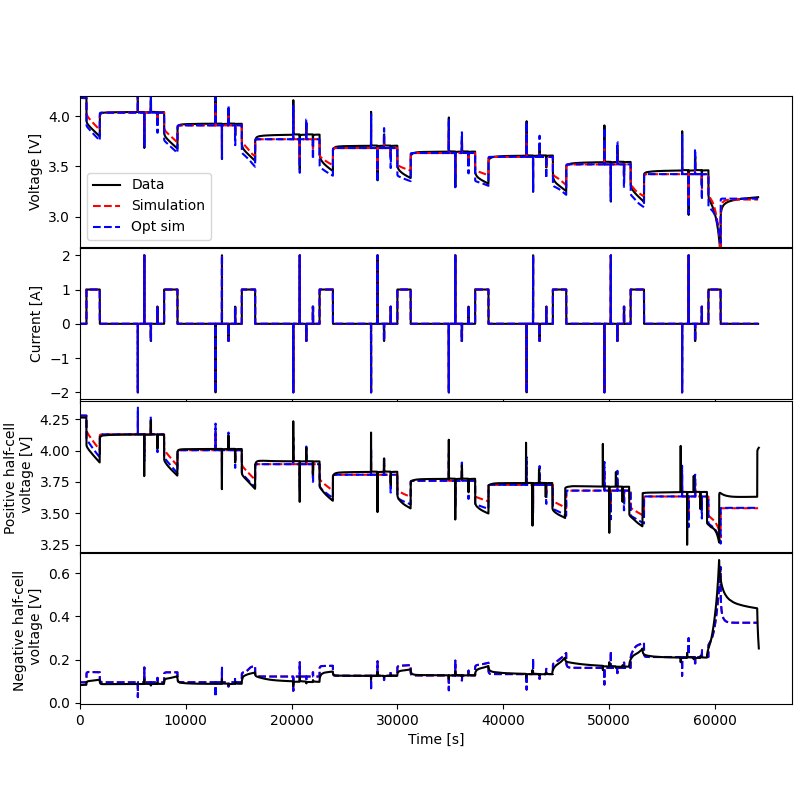

RMSE full:  53.46257690530229
RMSE neg:  34.475608751827586
RMSE pos:  100.05009714595326


In [27]:
%matplotlib widget
V_offset = 3.34+0.084
t = sol["Time [s]"].entries
I = sol["Current [A]"].entries
Vt = sol["Terminal voltage [V]"].entries

t_opt = sol_opt["Time [s]"].entries
I_opt = sol_opt["Current [A]"].entries
Vt_opt = sol_opt["Terminal voltage [V]"].entries

fig,ax = plt.subplots(4,1,figsize=(8,8), sharex=True)
plt.subplots_adjust(hspace=0.01, wspace=0.01, left=0.1, right=0.99, bottom=0.12)

# plot full cell voltage
ax1 = ax.flat[0]
ax1.plot(t_data,V_data,'k', label = 'Data')
ax1.plot(t,Vt,'r--', label = 'Simulation')
ax1.plot(t_opt,Vt_opt,'b--', label = 'Opt sim')
ax1.set_xlim(left=0)
ax1.set_ylabel('Voltage [V]')
ax1.legend(loc="lower left")

# plot current
ax2 = ax.flat[1]
ax2.plot(t_data,I_data,'k')
ax2.plot(t,I,'r--')
ax2.plot(t_opt,I_opt,'b--')
ax2.set_xlim(left=0)
ax2.set_ylabel('Current [A]')

# plot pos voltage
ax4 = ax.flat[2]
Vpos_elec =sol['Positive electrode 3E potential [V]'].entries
# Vpos_surf_pot=sol['Positive electrode surface potential difference at separator interface [V]'].entries
Vpos_elec_opt =sol_opt['Positive electrode 3E potential [V]'].entries
ax4.plot(t,Vpos_elec,'r--', label = "Electrode 3E potential")
ax4.plot(t,Vpos_elec_opt,'b--', label = "Electrode 3E potential")
# ax4.plot(t,Vpos_surf_pot,'b--', label = "Electrode surface potential difference at separator interface")
ax4.plot(t_data_vdf,V_offset + V_pos_data,'k',label = 'Data')
ax4.set_xlim(left=0)
ax4.set_ylabel('Positive half-cell \n voltage [V]')
# ax4.legend(loc="lower left")


# plot neg voltage
ax3 = ax.flat[3]
Vneg_elec =sol['Negative electrode 3E potential [V]'].entries
Vneg_elec_opt =sol['Negative electrode 3E potential [V]'].entries
# Vneg_surf_pot=sol['Negative electrode surface potential difference at separator interface [V]'].entries
ax3.plot(t,Vneg_elec,'r--',label = "Electrode 3E potential")
ax3.plot(t,Vneg_elec_opt,'b--',label = "Electrode 3E potential")
# ax3.plot(t,Vneg_surf_pot,'b--', label = "Electrode surface potential difference at separator interface")
ax3.plot(t_data_vdf,V_offset-V_neg_data,'k',label = 'Data')
ax3.set_xlim(left=0)
ax3.set_ylabel('Negative half-cell \n voltage [V]')
ax3.set_xlabel('Time [s]')
# ax3.legend(loc="upper left")

# set axis limits
ax1.set_ylim([2.7, 4.2])


# ax4.set_ylim([2.7, 4.2])
# ax3.set_ylim([-.05, -0.4])
# ax1.set_ylim([3.5, 4.2])
# ax3.set_ylim([.05, 0.35])

plt.show()


# calculate rmses 
rmses = []
for (v_sim, v_data, t_test_data) in zip([Vt, Vneg_elec, Vpos_elec, Vt_opt, Vneg_elec_opt, Vpos_elec_opt],[V_data, V_offset-V_neg_data, V_offset + V_pos_data]*2, [t_data, t_data_vdf,t_data_vdf]*2): 
    voltage_difference = (v_sim - np.interp(t,t_test_data,v_data))*1000
    rmses.append(np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference)))
rmse_full = rmses[0]
rmse_neg = rmses[1]
rmse_pos = rmses[2]
# voltage_difference = (Vt - V_data[range(len(Vt))])*1000
# rmse = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
# print("Checking full cell voltage lengths for RMSE: ", len(Vt), len(V_data), "RMSE (mV) :", rmse)
print('RMSE full: ', rmse_full)
print('RMSE neg: ', rmse_neg)
print('RMSE pos: ', rmse_pos)


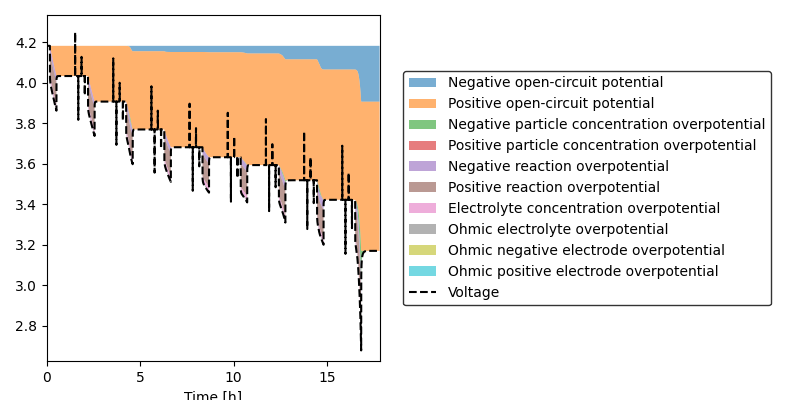

(2.5, 4.5)

In [18]:
fig, ax = pybamm.plot_voltage_components(sol,split_by_electrode=True)
ax.set_ylim([2.5,4.5])

## Archive

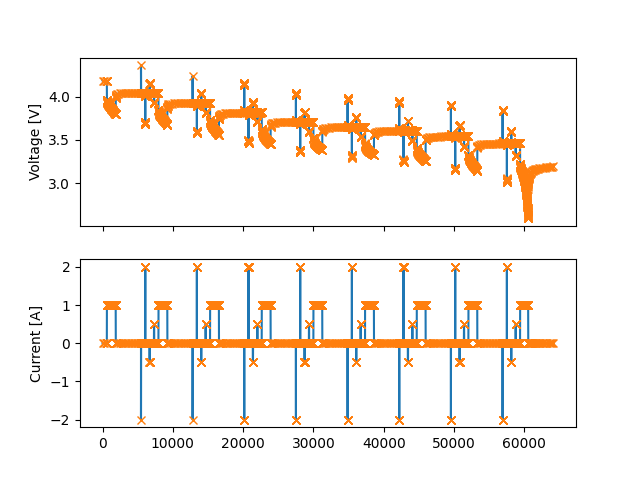

In [19]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_data, I_data, V_data = downsample_data(t_data0,I_data0,V_data0,5e-3,.5,230)
fig,ax = plt.subplots(2,1, sharex=True)
ax1 = ax.flat[0]
ax1.plot(t_data0,V_data0)
ax1.plot(t_data,V_data,'x')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data0,I_data0)
ax2.plot(t_data,I_data,'x')
ax2.set_ylabel('Current [A]')
plt.show()

In [20]:
#parameter_values = pybamm.ParameterValues("Siegel2022")
import Siegel2022
param_dict = Siegel2022.get_parameter_values()
#param_dict = {"a": 1, "b": 2, "c": 3}
parameter_values = pybamm.ParameterValues(param_dict)   
print(f"parameter values are {parameter_values}")

parameter_values.update(
    {
        "Negative electrode active material volume fraction": 0.66735,
        "Positive electrode active material volume fraction": 0.70513,
    #    "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
    #    "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        "Lower voltage cut-off [V]": 2.7, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

q_init, x_init, y_init=JS_Get_xy_from_voltage(parameter_values,4)
print(q_init)
print(x_init)
print(y_init)

parameter values are {'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.38,
 'Cell cooling surface area [m2]': 0.41,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 3.92e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 3.5,
 'Dead lithium decay constant [s-1]': 1e-06,
 'Dead lithium decay rate [s-1]': <function SEI_limited_dead_lithium_OKane2022 at 0x000001C1E7F2C700>,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 5.0,
 'Electrode height [m]': 0.106,
 'Electrode width [m]': 1.225,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Dix at 0x000001C1E7F2C550>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Dix at 0x000001C1E7F2C4C0>,
 'Electron charge [C]': 1.602176634e-19,
 'Exchange-current den

NameError: name 'JS_Get_xy_from_voltage' is not defined

In [ ]:
def JS_Get_xy_from_voltage(parameter_values,initial_voltage):
    # First we solve for x_100 and y_100
    param = pybamm.LithiumIonParameters()
    Vmin = 2.8
    Vmax = 4.2
    Q_n = parameter_values.evaluate(param.n.Q_init)
    Q_p = parameter_values.evaluate(param.p.Q_init)
    Q_Li = parameter_values.evaluate(param.Q_Li_particles_init)
    print(Q_n)
    print(Q_p)
    print(Q_Li)

    U_n = param.n.prim.U
    U_p = param.p.prim.U
    T_ref = param.T_ref

    model = pybamm.BaseModel()

    x_100 = pybamm.Variable("x_100")
    y_100 = (Q_Li - x_100 * Q_n) / Q_p

    y_100_min = 1e-10

    x_100_upper_limit = (Q_Li - y_100_min*Q_p)/Q_n
    print(x_100_upper_limit)
    model.algebraic = {x_100: U_p(y_100, T_ref) - U_n(x_100, T_ref) - Vmax}

    model.initial_conditions = {x_100: x_100_upper_limit}

    model.variables = {
        "x_100": x_100,
        "y_100": y_100
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])

    x_100 = sol["x_100"].data[0]
    y_100 = sol["y_100"].data[0]

    for var in ["x_100", "y_100"]:
        print(var, ":", sol[var].data[0])

    # Based on the calculated values for x_100 and y_100 we solve for x_0
    model = pybamm.BaseModel()

    x_0 = pybamm.Variable("x_0")
    Q = Q_n * (x_100 - x_0)
    y_0 = y_100 + Q/Q_p

    model.algebraic = {x_0: U_p(y_0, T_ref) - U_n(x_0, T_ref) - Vmin}
    model.initial_conditions = {x_0: 0.1}

    model.variables = {
        "Q": Q,
        "x_0": x_0,
        "y_0": y_0,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])
    Q=sol["Q"].data[0]

    for var in ["Q", "x_0", "y_0"]:
        print(var, ":", sol[var].data[0])


    # Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
    Q_init = pybamm.Variable("Q_init")

    model.algebraic = {Q_init: U_p(y_100-(Q_init-Q)/Q_p, T_ref) - U_n(x_100+(Q_init-Q)/Q_n, T_ref) - initial_voltage}
    model.initial_conditions = {Q_init: Q}

    model.variables = {
        "Q_init": Q_init,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])


    for var in ["Q_init"]:
        print(var, ":", sol[var].data[0])
    Q_init=sol["Q_init"].data[0]
    return Q_init, x_100+(Q_init-Q)/Q_n, y_100-(Q_init-Q)/Q_p

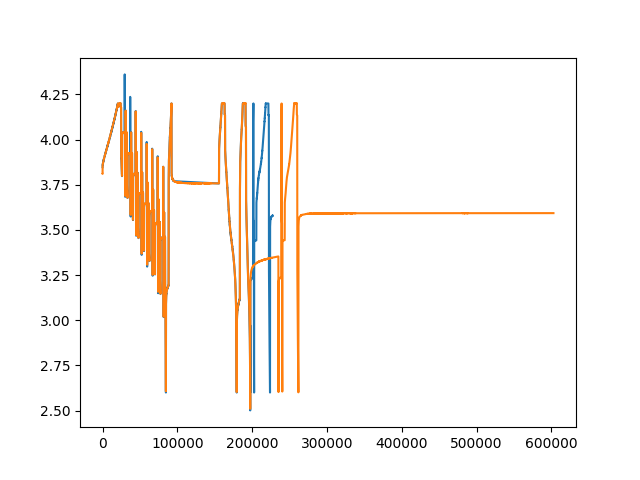

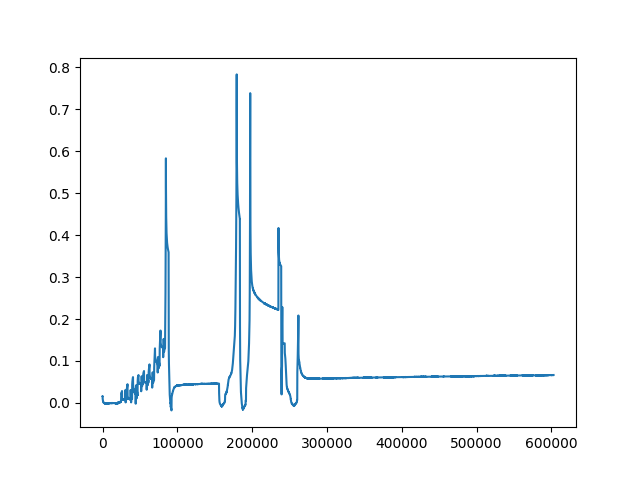

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


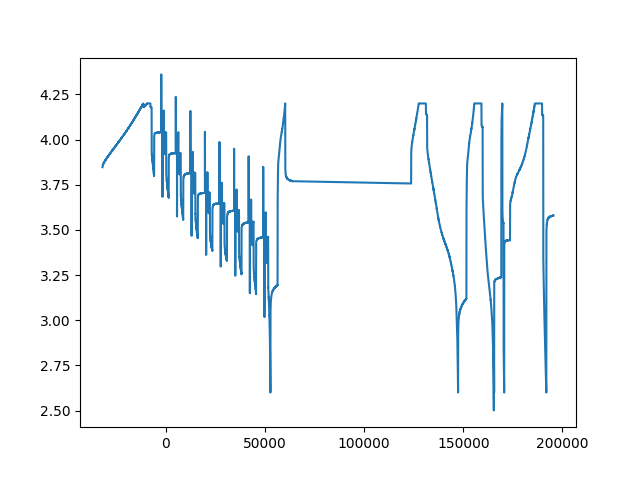

In [ ]:
raw_cycler_data=c.data.raw

start_time_exp=vdf_data["Timestamp"][0]/1000 # epoch time time in ms and convert to s
start_time_arbin=raw_cycler_data["date_time"].iloc[0].value/1e9+3600*4-1855 # UTC offset for EST, need to also be cognizent of DST?


fig, ax = plt.subplots(1, 1)
ax.plot(raw_cycler_data["test_time"],raw_cycler_data["voltage"],vdf_data["Test Time"]+start_time_exp-start_time_arbin,vdf_data["Potential"])
plt.show()

fig, ax = plt.subplots(1, 1)
ax.plot(vdf_data["Test Time"]+start_time_exp-start_time_arbin,3.345+0.0007-vdf_data["Vneg"])
plt.show()

timtot=raw_cycler_data["test_time"]
find_dupe_times=timtot.duplicated(keep='first')
timtot[find_dupe_times]=timtot[find_dupe_times]+2e-3
find_dupe_times2=timtot.duplicated(keep='first')
t_start = 32000
t_end = 62000
#t_start=163648 #C/4 discharge

t_dataF=timtot.to_numpy().flatten()-t_start
V_dataF=(raw_cycler_data["voltage"].values).flatten()
I_dataF=(raw_cycler_data["current"].values).flatten()
print(type(t_dataF))

print(type(I_dataF))
fig, ax = plt.subplots(1, 1)
ax.plot(t_dataF,V_dataF)
plt.show()




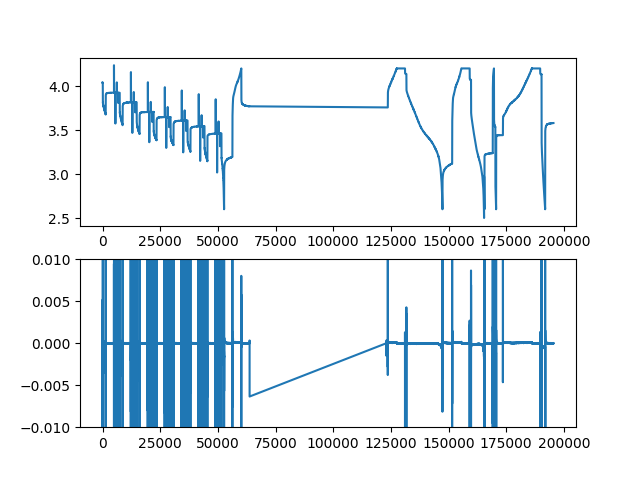

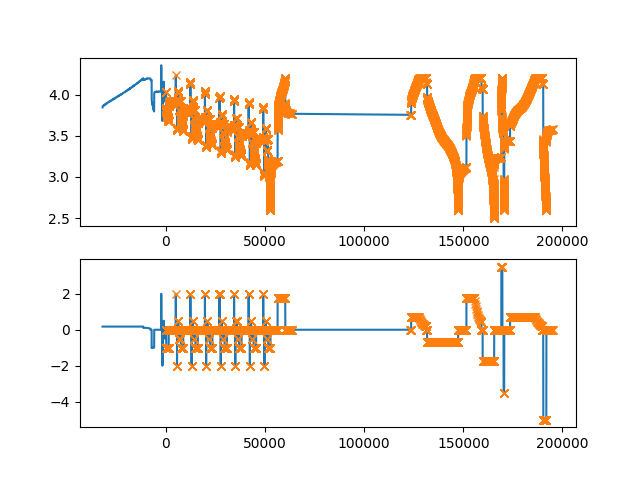

In [ ]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    fig,ax = plt.subplots(2,1)
    ax1 = ax.flat[0]
    ax1.plot(t,v)
    ax2 = ax.flat[1]
    ax2.plot(t,deriv_V)
    ax2.set_ylim([-.01, .01])
    #ax2.plot(t_data,I_data,'x')
    plt.show()

    dv_changes=abs(deriv_V)>dv
    #dv_changes=(np.abs(np.diff(v, prepend=0)/np.diff(t, prepend=0))>dv) + (np.abs(np.diff(v, append=0)/np.diff(t, append=0))>dv)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_data,I_data,V_data=downsample_data(t_dataF[t_dataF>=0],I_dataF[t_dataF>=0],V_dataF[t_dataF>=0],5e-3,.5,230)
fig,ax = plt.subplots(2,1)
# plt.title(str(cells[i]) + "Input Data")

#%matplotlib ipympl
ax1 = ax.flat[0]
ax1.plot(t_dataF,V_dataF)
ax1.plot(t_data,V_data,'x')
ax2 = ax.flat[1]
ax2.plot(t_dataF,I_dataF)
ax2.plot(t_data,I_data,'x')

plt.show()

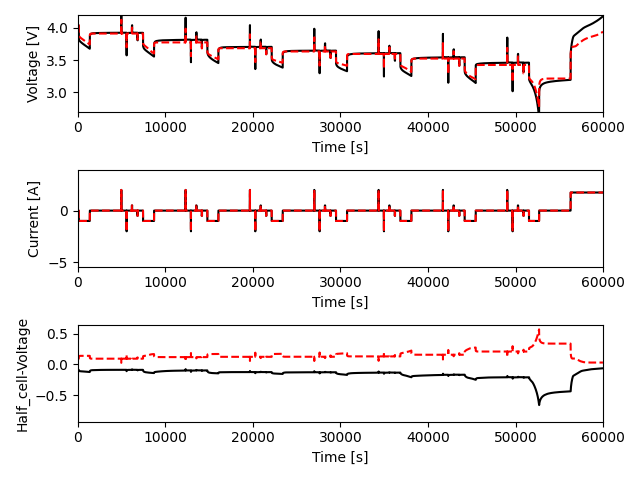

Checking Voltage lengths for RMSE:  2457 4142 RMSE (mV) : 67.14671165688657


In [ ]:

#%matplotlib widget
fig,ax = plt.subplots(3,1)
# plt.title(str(cells[i]) + "Input Data")
ax1 = ax.flat[0]
ax1.plot(t_data,V_data,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data,I_data,'k')
ax2.plot(t,-I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
#Vneg_elec =sol['X-averaged separator electrolyte potential [V]'].entries
Vneg_elec=sol['Negative electrode 3E potential [V]'].entries
#Vneg_surf_pot=sol['Negative electrode reaction overpotential [V]'].entries[10,:]
#Vneg_surf_pot=sol['X-averaged negative electrode surface potential difference [V]'].entries
Vneg_surf_pot=sol['Negative electrode surface potential difference at separator interface [V]'].entries
ax3 = ax.flat[2]
ax3.plot(vdf_data["Test Time"]+start_time_exp-start_time_arbin-t_start,-3.34-0.084+vdf_data["Vneg"],'k')
ax3.plot(t,Vneg_elec,'r--')
#ax3.plot(t,-Vneg_surf_pot,'b--')
ax3.set_xlim(left=0)
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Half_cell-Voltage')
ax3.set_xlim([0,t_end])
ax2.set_xlim([0,t_end])
ax1.set_xlim([0,t_end])
ax1.set_ylim([2.7, 4.2])
#ax3.set_ylim([-.05, -0.7])
# ax1.set_ylim([3.5, 4.2])
# ax3.set_ylim([-.05, -0.25])

#ax1.set_ylim([4.05, 4.1])
fig.tight_layout()
plt.show()

voltage_difference = (Vt - V_data[range(len(Vt))])*1000
rmse = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
print("Checking Voltage lengths for RMSE: ", len(Vt), len(V_data), "RMSE (mV) :", rmse)

interactive(children=(FloatSlider(value=0.013885893191041356, description='t', max=16.66248879438349, min=0.01…

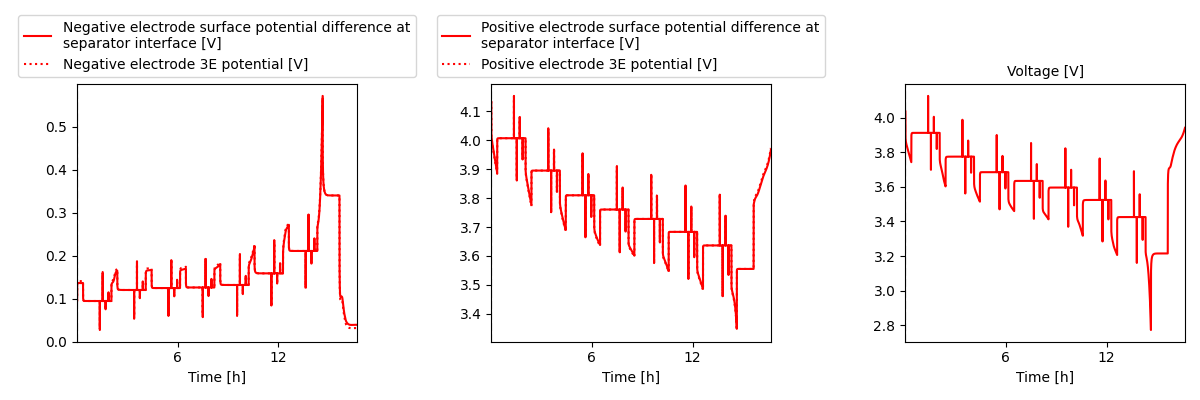

In [ ]:
sol.plot(
    [
        [
            "Negative electrode surface potential difference at separator interface [V]",
            "Negative electrode 3E potential [V]",
        ],
        [
            "Positive electrode surface potential difference at separator interface [V]",
            "Positive electrode 3E potential [V]",
        ],
        "Voltage [V]",
    ]
)

In [ ]:
def filtering(hppc_data_raw):

    if 'Weight' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Weight'], axis=1)
    if 'Diff' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Diff'], axis=1)
    if 'Binary' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Binary'], axis=1)

    capacity = 3.5

    # Clipping dataframe to just first block of RPTs
    df = hppc_data_raw.copy()
    df['Time'] = df.Timestamp - df.Timestamp.min()
    df['index_col'] = df.index # Track index position of each dataframe so we're reorganizing the reduced dataframe appropriately

    # Intializing Weight and Binary columns
    df.insert(loc=0, column='Binary', value=0)
    df.insert(loc=0, column='Weight', value=0)

    # Current sign change tracking
    df.loc[df['Current (A)'] > 0, 'Binary'] = 1
    df.loc[df['Current (A)'] < 0, 'Binary'] = 1
    current_sign_change = df[df.Binary.diff() !=0].index.tolist()

    # 50 seconds after current sign change
    for x in range(0, 50):

        csign_change = [i + x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # 10 seconds before current sign change
    for x in range(0, 10):

        csign_change = [i - x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # Any non-zero current should not be reduced
    df.loc[df['Current (A)'] != 0, 'Weight'] = 1

    # SOC setting should be sampled at a lower rate
    df.loc[df.DataTag == 0.5, 'Weight'] = 2
    df.loc[df.DataTag == -0.5, 'Weight'] = 2

    df['DateTime'] = pd.to_datetime(df.Time, unit='s')

    # Resampling dataframe sections accordingly
    weight_1_df = df[df.Weight == 1]
    needs_resampling = df[df.Weight == 0]
    soc_setting = df[df.Weight == 2]
    resampled = needs_resampling.resample('10S', on='DateTime').mean()
    resampled_soc_setting = soc_setting.resample('10s', on='DateTime').mean()
    resampled_df = pd.concat([weight_1_df, resampled, resampled_soc_setting])
    resampled_df = resampled_df.sort_values(by=['index_col'])

    pct_reduced = (df.shape[0] - resampled_df.shape[0]) / df.shape[0] * 100
    print('% reduced', pct_reduced)
    return resampled_df

In [ ]:
# def execution(inputDict, cells):

#     # STEP 1: Inputs for Objective Function
#     parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
#     spme = pybamm.lithium_ion.SPMe()

#     # Objective Function Inputs
#     # initial_guess = [4.4 * 10 ** (-15), 5.0 * 10 ** (-15), 4.824 * 10 ** (-6), 1.061 * 10 ** (-6)]
#     # lb = [10**(-18), 10**(-18), 10**(-9), 10**(-9)]
#     # ub = [10**(-12), 10**(-12), 10**(-3), 10**(-3)]

#     # STEP 2: Objective Function
#     # 'param0': 7.562822125242107e-13, 'param1': 2.3907778449783082e-14, 'param2': 6.5068308270099e-08, 'param3': 0.0001093915587019561
#     # 'param0': 3.2939804080443717e-13, 'param1': 2.4925614356710155e-14, 'param2': 4.006024683515786e-08, 'param3': 5.863856334652709e-05}
#     # 'param0': 6.748678940622972e-14, 'param1': 1.0122133310725916e-13, 'param2': 1.3715539078341868e-07, 'param3': 1.2178795378580133e-06
#     param0 = 6.748678940622972e-14
#     param1 = 1.0122133310725916e-13
#     param2 = 1.3715539078341868e-07
#     param3 = 1.2178795378580133e-06  
#     start_time = time.time()
#     rmse = np.zeros(len(cells))
#     for i in range(len(cells)):
#         t_data = inputDict[str(cells[i])][0]
#         I_data = inputDict[str(cells[i])][1]
#         V_data = inputDict[str(cells[i])][2]
#         parameter_values = inputDict[str(cells[i])][3] 
#         parameter_values.update(
#             {
#                 "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
#                 "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
#                 "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
#                 "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
                
#                 })           
        
#         # Run Simulation
#         spme = pybamm.lithium_ion.SPMe()
#         sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
#                             solver=pybamm.CasadiSolver("safe"))
#         sol = sim_0.solve(
#             t_eval=t_data, 
#             inputs = {
#             "posDiffusion": param0, 
#             "negDiffusion": param1, 
#             "posKinetics": param2,
#             "negKinetics": param3
#             })

#         t_after = sol["Time [s]"].entries
#         I_after = sol["Current [A]"].entries
#         # Q_after = sol['Discharge capacity [A.h]'].entries
#         Vt_after = sol["Terminal voltage [V]"].entries

#         # Analyze Simulation Results

#         Vt_after1 = np.interp(t_data, t_after, Vt_after)
#         t_after1 = np.interp(t_data, t_after, t_after)
#         voltage_difference = Vt_after1 - V_data
#         rmse[i] = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
#         print("Checking Voltage lengths for RMSE: ", len(Vt_after1), len(V_data))
        
#         fig,ax = plt.subplots(2,1)
#         plt.title(str(cells[i]) + "Optimized Results")
#         ax1 = ax.flat[0]
#         ax1.plot(t_data,V_data,'k')
#         ax1.plot(t_after,Vt_after,'r--')
#         ax1.set_xlim(left=0)
#         ax1.set_xlabel('Time [s]')
#         ax1.set_ylabel('Voltage [V]')
#         ax2 = ax.flat[1]
#         ax2.plot(t_data,I_data,'k')
#         ax2.plot(t_after,-I_after,'r--')
#         ax2.set_xlim(left=0)
#         ax2.set_xlabel('Time [s]')
#         ax2.set_ylabel('Current [A]')
#         fig.tight_layout()

#         rmseOutput = voltage_difference
#         df = pd.DataFrame({"Test Time": t_data, "Test Voltage": V_data, "Model Time": t_after1, "Model Voltage": Vt_after1, "RMSE": rmseOutput})
#         df.to_csv(str(cells[i]) + "RMSE-Time.csv")

#         fig,ax = plt.subplots(2,1)
#         plt.title(str(cells[i]) + "RMSE-Time")
#         ax1 = ax.flat[0]
#         ax1.plot(t_data,rmseOutput*1000,'k')
#         ax1.set_xlim(left=0)
#         ax1.set_xlabel('Time [s]')
#         ax1.set_ylabel('RMSE [mV]')
#         fig.tight_layout()

#     global rmseAverage
#     end_time = time.time()
#     single_guess_time = (end_time - start_time)/60 
#     rmseAverage = np.sum(rmse)/len(rmse)
#     print("time to calculate: ", single_guess_time)
#     print("guess parameters and average RMSE: ", param0, param1, param2, param3, rmseAverage)
#     return(Vt_after1, V_data,t_after1, I_after)

In [ ]:
# ###### Revise Start ######
# #cells = [['CELL041', 'P25C', '5P0PSI'], ['CELL081', 'P25C', '5P0PSI'], ['CELL016', 'P25C', '5P0PSI']] # cells analyzing together
# cells = [['CELL016', 'P25C', '5P0PSI']] # cells analyzing together
# #cells = [['CELL016', 'P25C', '5P0PSI']] # cells analyzing together

# #cells = [['CELL081', 'P25C', '5P0PSI']]#, ['CELL016', 'P25C', '5P0PSI']] # cells analyzing together

# inputDict = {}

# for i in range(len(cells)):
#     parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
#     spme = pybamm.lithium_ion.SPMe()
#     hppc_data_raw = pd.DataFrame()


#     # with open('C:\\Users\\rzhgp5\\Downloads\\Misc_UM\\' + str(cells[i]) + ".pickle", "rb") as f:
#         # combinedDict = pickle.load(f)
#     combinedDict=data
#     if cells[i] == ['CELL041', 'P25C', '5P0PSI'] or cells[i] == ['CELL081', 'P25C', '5P0PSI'] or cells[i] == ['CELL016', 'P25C', '5P0PSI']:

#         if cells[i] == ['CELL041', 'P25C', '5P0PSI']:
#             temperature = 25
#             C_n_init = 4.0352
#             C_p_init = 5.495
#             x_init = 0.8613 # x0 or x100 depending on starting at 0 SOC or 1 SOC
#             y_init = 0.3096 # use 0 if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC

#         elif cells[i] == ['CELL081', 'P25C', '5P0PSI']:
#             temperature = 25
#             C_n_init = 4.0458
#             C_p_init = 5.4828
#             x_init = 0.861 # x0 or x100 depending on starting at 0 SOC or 1 SOC
#             y_init = 0.3083 # use 0  if a negati if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC

#         elif cells[i] == ['CELL016', 'P25', '5P0PSI']:
#             temperature = 25
#             C_n_init = 4.0846
#             C_p_init = 5.5243
#             x_init = 0.8658 # x0 or x100 depending on starting at 0 SOC or 1 SOC
#             y_init = 0.30638 # use 0  value # y0 or y100 depending on starting at 0 SOC or 1 SOC

#         count = 0
#         for key, value in combinedDict.items():
#             if value[0] == 5 or value[0] == 3 or value[0] == 1:
#                 # if count >0:
#                 count += 1
#                 df = pd.DataFrame(value[1])
#                 hppc_data_raw = pd.concat([hppc_data_raw, df], ignore_index=True)
#                 # if count > 8:
#                 #     break
                
#             # elif value[0] == -5 or value[0] == -3:
#             #     break

#         hppc_data_raw = hppc_data_raw.sort_values(by = ['Timestamp', 'Test Time (s)'])
#         if max(hppc_data_raw['Potential (V)']) >4.210: 
#             raise ("Warning >10mV overshoot at initial OCV")
            
#         #print(max(hppc_data_raw["Potential (V)"]))
#         hppc_data_raw.loc[hppc_data_raw['Potential (V)'] > 4.2, 'Potential (V)'] = 4.2
#         index_to_drop = hppc_data_raw[hppc_data_raw["Potential (V)"] < 2.7].index.min()
#         hppc_data_raw = hppc_data_raw.loc[:index_to_drop - 1]
#         hppc_data_raw = filtering(hppc_data_raw)

#         # Experimental data
#         hppc_data = hppc_data_raw.dropna(subset=['Current (A)', 'Potential (V)', 'Time'])
#         hppc_data = hppc_data.rename(columns={'Current (A)': 'Current [A]', 'Potential (V)': 'Voltage [V]', 'Time': 'Time [s]'})
#         data_time = hppc_data['Time [s]'] - hppc_data['Time [s]'][0]
#         data_current = hppc_data['Current [A]'].values
#         data_voltage= hppc_data['Voltage [V]'].values

#         if cells[i] == ['CELL081', 'P25C', '5P0PSI']:
#             index = 5800*2
#             data_voltage = data_voltage[index:]
#             data_current = data_current[index:]
#             data_time = data_time[index:]
#             data_time = data_time.reset_index(drop=True)
#             data_time = data_time - data_time[0]

#         elif cells[i] == ['CELL041', 'P25C', '5P0PSI']:
#             index = 5800*2
#             l = index
#             data_voltage = data_voltage[index:]
#             data_current = data_current[index:]
#             data_time = data_time[index:]
#             data_time = data_time.reset_index(drop=True)
#             data_time = data_time - data_time[0]  

#         elif cells[i] == ['CELL016', 'P25C', '5P0PSI']:
#             index = 5800*2+2800
#             l = index
#             data_voltage = data_voltage[index:]
#             data_current = data_current[index:]
#             data_time = data_time[index:]
#             data_time = data_time.reset_index(drop=True)
#             data_time = data_time - data_time[0]

#         ###### Revise End ######

#         #interpolation
#         t_data = np.arange(0,data_time.iloc[-1],0.1)
#         I_data = np.interp(t_data, data_time, data_current, left=None, right=None, period=None)
#         V_data = np.interp(t_data, data_time, data_voltage, left=None, right=None, period=None)   
#         # t_data = np.array(list(data_time))
#         # I_data = np.array(list(data_current))
#         # V_data = np.array(list(data_voltage))
        
#         parameter_values.update({"Lower voltage cut-off [V]": 2.7, "Upper voltage cut-off [V]": 4.2}, check_already_exists=False)
#         param = spme.param
#         parameter_values.update(
#             {
#                 "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
#                 "Maximum concentration in negative electrode [mol.m-3]":	29637,
#                 },check_already_exists=False,)    

#         C_n_init = 4.0458 
#         C_p_init = 5.4828
#         x_init = 0.861
#         y_init = 0.3083
#         eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
#         eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
#         cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
#         cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

#         # Updating parameters for initialization
#         parameter_values.update(
#             {
#                 "Negative electrode active material volume fraction": eps_n_init,
#                 "Positive electrode active material volume fraction": eps_p_init,
#                 "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
#                 "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
#                 "Initial temperature [K]": 273.15+25,
#                 "Ambient temperature [K]": 273.15+25,
#             },check_already_exists=False,)

#         Vmin = 2.7
#         Vmax = 4.2
#         esoh_model = pybamm.lithium_ion.ElectrodeSOH()
#         esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
#         esoh_solver = pybamm.lithium_ion.ElectrodeSOHSolver(parameter_values, param)
#         Cn = parameter_values.evaluate(param.n.cap_init)
#         Cp = parameter_values.evaluate(param.p.cap_init)
#         eps_n = parameter_values["Negative electrode active material volume fraction"]
#         eps_p = parameter_values["Positive electrode active material volume fraction"]
#         c_n_max = parameter_values.evaluate(param.n.prim.c_max)
#         c_p_max = parameter_values.evaluate(param.p.prim.c_max)
#         n_Li_init = parameter_values.evaluate(param.n_Li_particles_init)

#         esoh_sol = esoh_sim.solve(
#             [0],
#             inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
#             solver=pybamm.AlgebraicSolver(),)

#         x100=esoh_sol["x_100"].data[0]
#         y100=esoh_sol["y_100"].data[0]
#         x0=esoh_sol["x_0"].data[0]
#         y0=esoh_sol["y_0"].data[0]
        
#         timescale = parameter_values.evaluate(spme.timescale)
#         # discharge is positive current in PyBaMM
#         current_interpolant = pybamm.Interpolant(t_data, -I_data, timescale * pybamm.t)
#         parameter_values["Current function [A]"] = current_interpolant
#         parameter_values.update({"Lower voltage cut-off [V]": 2.7, "Upper voltage cut-off [V]": 4.22}, check_already_exists=False)

#         sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, solver=pybamm.CasadiSolver("safe"))
#         sol = sim_0.solve(t_eval=t_data)

#         t = sol["Time [s]"].entries
#         I = sol["Current [A]"].entries
#         Q = sol['Discharge capacity [A.h]'].entries
#         Vt = sol["Terminal voltage [V]"].entries

#         #print("Voltage Comparison for " + str(cells[i]) + ":", V_data[0], Vt[0], abs(V_data[0]-Vt[0]))

#         fig,ax = plt.subplots(2,1)
#         plt.title(str(cells[i]) + "Input Data")
#         ax1 = ax.flat[0]
#         ax1.plot(t_data,V_data,'k')
#         ax1.plot(t,Vt,'r--')
#         ax1.set_xlim(left=0)
#         ax1.set_xlabel('Time [s]')
#         ax1.set_ylabel('Voltage [V]')
#         ax2 = ax.flat[1]
#         ax2.plot(t_data,I_data,'k')
#         ax2.plot(t,-I,'r--')
#         ax2.set_xlim(left=0)
#         ax2.set_xlabel('Time [s]')
#         ax2.set_ylabel('Current [A]')
#         fig.tight_layout()

#         inputDict.update({str(cells[i]): [t_data, I_data, V_data, parameter_values]})

# cells = [['CELL016', 'P25C', '5P0PSI']] 
# #cells = [['CELL081', 'P25C', '5P0PSI']] 

# v_model, v_test, t_model, current_model =  execution(inputDict, cells)

TypeError: ParameterValues.__init__() missing 1 required positional argument: 'values'

15.085432652766753

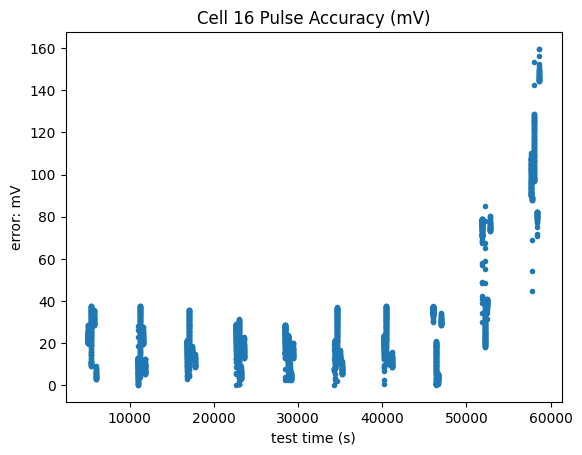

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (current_model < threshold_low) | (current_model > threshold_high)
sign_index_model = np.where(condition_model)[0]
Vpulse_model = v_model[sign_index_model]
Vpulse_test = v_test[sign_index_model]
t = t_model[sign_index_model]

error = [(Vpulse_model[i] - Vpulse_test[i])**2.0 for i in range(len(Vpulse_model))]
error = [np.sqrt(i) * 1000 for i in error]
RMSE = np.sqrt(np.mean(error))

plt.plot(t,error,'.')
plt.xlabel('test time (s)')
plt.ylabel('error: mV')
plt.title("Cell 16 Pulse Accuracy (mV)") 

error_whole = [((v_model[i] - v_test[i])**2.0)**0.5*1000 for i in range(len(v_test))]
RMSE = np.mean(error_whole[:49999])
# plt.plot(t_model[:49999],error_whole[:49999])
# plt.xlabel('test time (s)')
# plt.ylabel('error: mV')
# RMSE
if not cell_output_dict: 
    cell_output_dict= {}
cell_output_dict["cell16"] = [v_test,v_model,t_model, Vpulse_model, Vpulse_test,t,error ] 
RMSE

In [ ]:
hppc_data

,Weight,Binary,Timestamp,Test Time (s),Current [A],Voltage [V],DataTag,Discharge Capacity (Ah),Time [s],index_col,DateTime
0,1.0,0.0,1.672783e+09,0.0,0.00000,3.34390,0.0,0.00000,0.0,0.0,1970-01-01 00:00:00.000000000
1,1.0,0.0,1.672783e+09,0.1,0.00000,3.34390,0.0,0.00000,0.1,1.0,1970-01-01 00:00:00.099999904
2,1.0,1.0,1.672783e+09,0.1,0.99980,3.44490,0.0,0.00000,0.1,2.0,1970-01-01 00:00:00.099999904
3,1.0,1.0,1.672783e+09,0.2,0.99980,3.44490,0.0,0.00000,0.2,3.0,1970-01-01 00:00:00.200000047
4,1.0,1.0,1.672783e+09,0.4,1.00000,3.45660,0.0,0.00000,0.4,4.0,1970-01-01 00:00:00.400000095
...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 22:38:40,2.0,1.0,1.672865e+09,81524.9,-0.30012,2.72963,-0.5,0.18580,81524.9,138910.5,NaT
1970-01-01 22:38:50,2.0,1.0,1.672865e+09,81534.9,-0.30003,2.72162,-0.5,0.18663,81534.9,138920.5,NaT
1970-01-01 22:39:00,2.0,1.0,1.672865e+09,81544.9,-0.30010,2.71349,-0.5,0.18749,81544.9,138930.5,NaT
1970-01-01 22:39:10,2.0,1.0,1.672865e+09,81554.9,-0.30006,2.70524,-0.5,0.18831,81554.9,138940.5,NaT


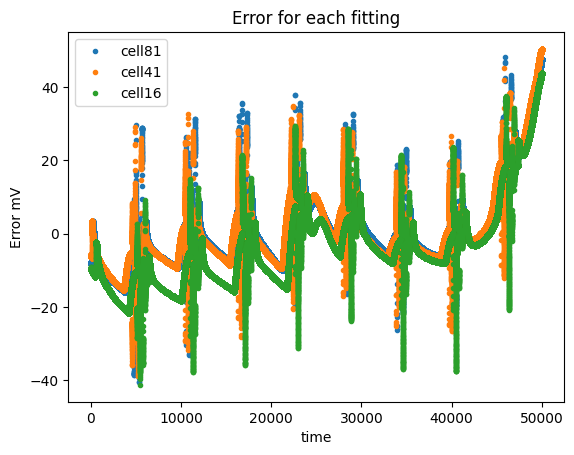

In [ ]:
for cell in cell_output_dict: 
    y = (cell_output_dict[cell][0] - cell_output_dict[cell][1])*1000
    x = cell_output_dict[cell][2]

    y = y[:500000]
    x = x[:500000]
    plt.plot(x,y,'.',label=cell)
plt.xlabel('time')
plt.ylabel('Error mV')
plt.title('Error for each fitting')
plt.legend()
plt.show()

In [ ]:
Vt_after1 = np.interp(t_data, t, Vt)
t_after1 = np.interp(t_data, t, t)
voltage_difference = Vt_after1 - V_data
len(t_after1), len(Vt_after1), len( 
#rmse[i] = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))

(664953, 664953)

In [ ]:
#Let's see if this black Screen's again. 
len(Vt), len(V_data)
#Calculate RMSE: 
error = [(Vt[i] - V_data[i])**2.0 for i in range(len(Vt))]
RMSE = np.sqrt(np.mean(error))
print(round(RMSE*1000,1), "mV error at C/3")

69.8 mV error at C/3


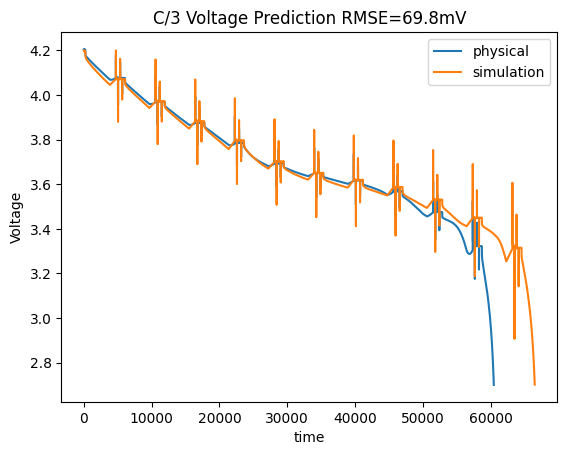

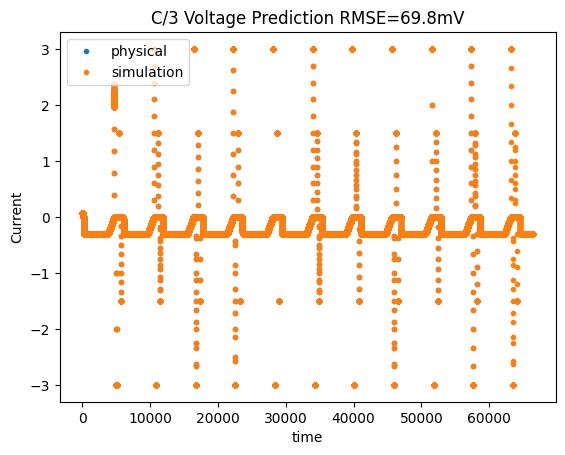

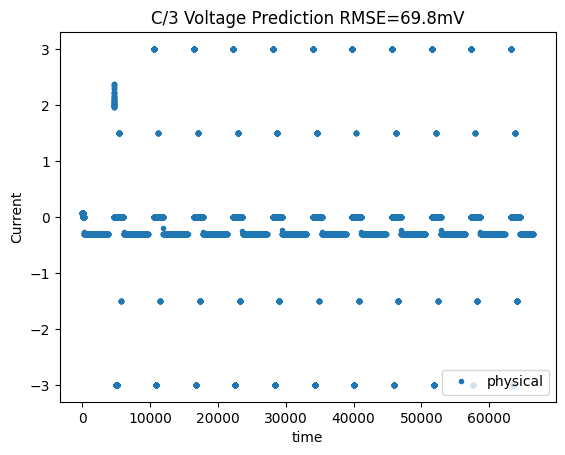

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t,Vt, label='physical')
plt.plot(t_data, V_data, label='simulation')
plt.xlabel('time')
plt.ylabel("Voltage")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

#min(df["Potential (V)"])
import matplotlib.pyplot as plt
plt.plot(t,-I, '.',label='physical',)
plt.plot(t_data, I_data ,'.',label='simulation')
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

plt.plot(data_time,data_current, '.',label='physical',)
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

In [ ]:
len(V_data), len(Vt)
len(t), len(t_data)

(604621, 664953)

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (I < threshold_low) | (I > threshold_high)
sign_index_model = np.where(condition_model)[0]
condition_test = (I_data < threshold_low) | (I_data > threshold_high)
sign_index_test = np.where(condition_test)[0]
Vpulse_model = V_data[sign_index_model]
Vpulse_test = V_data[sign_index_test]
len(Vpulse_test), len(Vpulse_model) 

(3030, 2753)

In [ ]:
cell_num.append(cells[0])
cell_errors.append(RMSE)
cell_voltage.append(Vt)
cell_prediction.append(V_data)
cell_v0.append(Vt[0])

In [ ]:
cell_output_dict = {}